In [21]:
# Install/import the required libraries

%pip install -q xgboost shap networkx seaborn


Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import

from pathlib import Path
from urllib.parse import urlparse

import io
import json
import tarfile
import tempfile

import boto3
import joblib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

In [2]:
# Define AWS configuration

region = boto3.Session().region_name

sm_client = boto3.client(
    "sagemaker",
    region_name=region
)

s3_client = boto3.client(
    "s3",
    region_name=region
)

best_training_job_name = (
    "umass-churn-hpo-260725-2158-009-d35ff02c"
)

pipeline_name = "UMassChurnPipeline"

# These should already exist in your earlier notebooks.
print("Region:", region)
print("Best training job:", best_training_job_name)

Region: us-east-1
Best training job: umass-churn-hpo-260725-2158-009-d35ff02c


In [3]:
bucket = "sagemaker-us-east-1-581187100103"
project_prefix = "customer-churn-sagemaker"
reports_dir = Path("../reports").resolve()

print("Report directory:", reports_dir)

Report directory: /home/sagemaker-user/customer-churn-sagemaker/reports


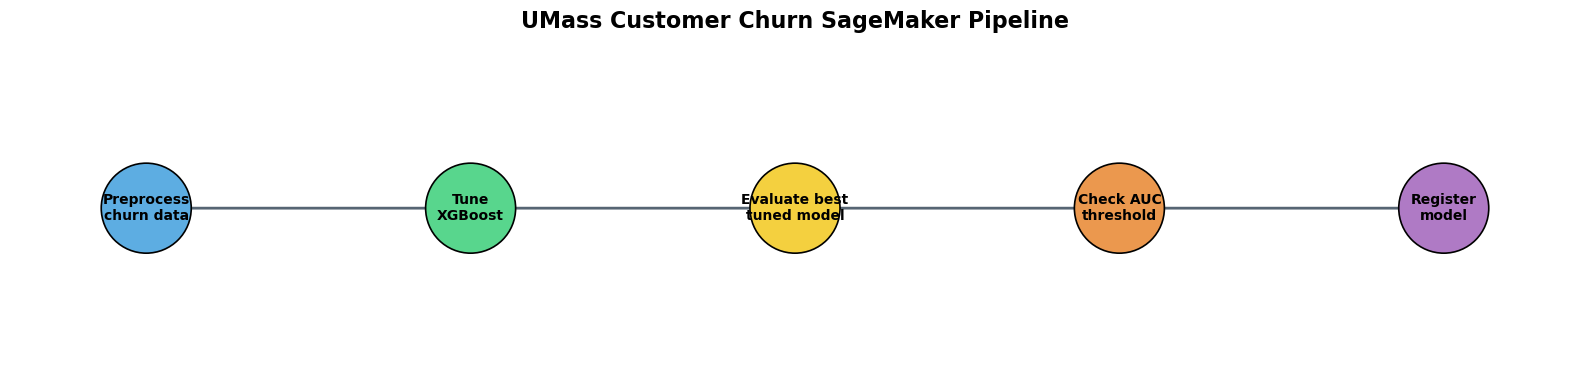

In [4]:
# Report 1: pipeline-graph.png

graph = nx.DiGraph()

nodes = {
    "PreprocessChurnData": "Preprocess\nchurn data",
    "TuneChurnXGBoost": "Tune\nXGBoost",
    "EvaluateBestTunedModel": "Evaluate best\ntuned model",
    "CheckChurnAUC": "Check AUC\nthreshold",
    "RegisterChurnModel": "Register\nmodel"
}

graph.add_nodes_from(nodes.keys())

graph.add_edges_from([
    ("PreprocessChurnData", "TuneChurnXGBoost"),
    ("TuneChurnXGBoost", "EvaluateBestTunedModel"),
    ("EvaluateBestTunedModel", "CheckChurnAUC"),
    ("CheckChurnAUC", "RegisterChurnModel")
])

positions = {
    "PreprocessChurnData": (0, 0),
    "TuneChurnXGBoost": (2, 0),
    "EvaluateBestTunedModel": (4, 0),
    "CheckChurnAUC": (6, 0),
    "RegisterChurnModel": (8, 0)
}

colors = [
    "#5DADE2",
    "#58D68D",
    "#F4D03F",
    "#EB984E",
    "#AF7AC5"
]

plt.figure(figsize=(16, 4))

nx.draw_networkx_nodes(
    graph,
    positions,
    node_color=colors,
    node_size=4200,
    edgecolors="black",
    linewidths=1.2
)

nx.draw_networkx_edges(
    graph,
    positions,
    arrows=True,
    arrowsize=25,
    width=2,
    edge_color="#566573"
)

nx.draw_networkx_labels(
    graph,
    positions,
    labels=nodes,
    font_size=10,
    font_weight="bold"
)

plt.title(
    "UMass Customer Churn SageMaker Pipeline",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    reports_dir / "pipeline-graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
# Report 2: tuning-results.csv

tuning_job_name = "umass-churn-hpo-260725-2158"

training_jobs = []
next_token = None

while True:
    request = {
        "HyperParameterTuningJobName": tuning_job_name,
        "SortBy": "FinalObjectiveMetricValue",
        "SortOrder": "Descending",
        "MaxResults": 50
    }

    if next_token:
        request["NextToken"] = next_token

    response = sm_client.list_training_jobs_for_hyper_parameter_tuning_job(
        **request
    )

    training_jobs.extend(
        response["TrainingJobSummaries"]
    )

    next_token = response.get("NextToken")

    if not next_token:
        break

print("Trials found:", len(training_jobs))

# create CSV

tuning_rows = []

for summary in training_jobs:
    job_name = summary["TrainingJobName"]

    job = sm_client.describe_training_job(
        TrainingJobName=job_name
    )

    row = {
        **job.get("HyperParameters", {}),
        "TrainingJobName": job_name,
        "TrainingJobStatus": job["TrainingJobStatus"],
        "FinalObjectiveValue": (
            summary
            .get("FinalHyperParameterTuningJobObjectiveMetric", {})
            .get("Value")
        ),
        "TrainingStartTime": job.get("TrainingStartTime"),
        "TrainingEndTime": job.get("TrainingEndTime"),
        "TrainingElapsedTimeSeconds": (
            job.get("TrainingTimeInSeconds")
        )
    }

    tuning_rows.append(row)

tuning_results_df = pd.DataFrame(tuning_rows)

tuning_results_df["FinalObjectiveValue"] = pd.to_numeric(
    tuning_results_df["FinalObjectiveValue"],
    errors="coerce"
)

tuning_results_df = tuning_results_df.sort_values(
    "FinalObjectiveValue",
    ascending=False
)

tuning_results_df.to_csv(
    reports_dir / "tuning-results.csv",
    index=False
)

tuning_results_df.head(10)

Trials found: 10


,_tuning_objective_metric,alpha,colsample_bytree,eta,eval_metric,lambda,max_depth,min_child_weight,num_round,objective,subsample,TrainingJobName,TrainingJobStatus,FinalObjectiveValue,TrainingStartTime,TrainingEndTime,TrainingElapsedTimeSeconds
0,validation:auc,2.465210057030828,0.7944288599464302,0.05972916223563948,auc,1.130446625747541,6,1.0602747761296238,200,binary:logistic,0.701081805747765,umass-churn-hpo-260725-2158-009-d35ff02c,Completed,0.98374,2026-07-25 22:06:13.102000+00:00,2026-07-25 22:07:02.234000+00:00,49
1,validation:auc,2.5818495792611094,0.7358334901031843,0.046424394082805166,auc,6.062795569138858,6,2.062458314678033,200,binary:logistic,0.95759968173562,umass-churn-hpo-260725-2158-007-2808a6e9,Completed,0.98278,2026-07-25 22:05:06.550000+00:00,2026-07-25 22:05:50.450000+00:00,44
2,validation:auc,4.92033890013226,0.6056999346645887,0.11499964012992787,auc,0.5518888864632215,7,8.44625402075436,200,binary:logistic,0.9223877685194181,umass-churn-hpo-260725-2158-002-707d6516,Completed,0.98275,2026-07-25 21:59:23.462000+00:00,2026-07-25 22:01:28.689000+00:00,125
3,validation:auc,2.8210483129514454,0.9492170827111802,0.25352445936517654,auc,2.9652780292628744,3,2.0387057390898775,200,binary:logistic,0.7385045606724435,umass-churn-hpo-260725-2158-008-96cc80dc,Completed,0.98273,2026-07-25 22:05:10.845000+00:00,2026-07-25 22:05:55.144000+00:00,45
4,validation:auc,0.9567367635024193,0.6876853840359409,0.09059409753580872,auc,0.70052368369019,10,2.633629220545439,200,binary:logistic,0.7196020340185149,umass-churn-hpo-260725-2158-006-a2d7f4b8,Completed,0.98231,2026-07-25 22:04:01.749000+00:00,2026-07-25 22:04:51.631000+00:00,50
5,validation:auc,4.624448305673136,0.8730968826005763,0.19218241649940554,auc,6.913096756754756,10,4.454325819852006,200,binary:logistic,0.7995379451202027,umass-churn-hpo-260725-2158-001-427d23df,Completed,0.98227,2026-07-25 21:59:22.130000+00:00,2026-07-25 22:01:27.050000+00:00,125
6,validation:auc,0.1355771652964749,0.7731298502710631,0.07122598579757668,auc,1.7183330069587934,4,2.0223556165872982,200,binary:logistic,0.7225062620346263,umass-churn-hpo-260725-2158-003-ce007b21,Completed,0.98217,2026-07-25 22:02:01.101000+00:00,2026-07-25 22:02:50.156000+00:00,49
7,validation:auc,3.686476676323636,0.9287039814126892,0.027810101651285786,auc,2.510328309643788,9,9.456134834798101,200,binary:logistic,0.7998159325800321,umass-churn-hpo-260725-2158-005-1060c34b,Completed,0.98210,2026-07-25 22:04:00.190000+00:00,2026-07-25 22:04:49.075000+00:00,49
8,validation:auc,2.080651347560028,0.9928352265597447,0.02663678184219022,auc,5.798031558055233,6,9.987449758661139,200,binary:logistic,0.9546810520613478,umass-churn-hpo-260725-2158-004-43d987b0,Completed,0.98158,2026-07-25 22:02:02.946000+00:00,2026-07-25 22:02:46.885000+00:00,44
9,validation:auc,4.940934869091267,0.655701555966925,0.029660336512497575,auc,1.1538299044276705,10,7.66049754053719,200,binary:logistic,0.9786636358265475,umass-churn-hpo-260725-2158-010-58614242,Completed,0.97979,2026-07-25 22:06:15.237000+00:00,2026-07-25 22:07:04.297000+00:00,49


In [6]:
# Get the best model artifact

best_job = sm_client.describe_training_job(
    TrainingJobName=best_training_job_name
)

model_s3_uri = (
    best_job["ModelArtifacts"]["S3ModelArtifacts"]
)

print("Model artifact:", model_s3_uri)

# Download it

def split_s3_uri(s3_uri):
    parsed = urlparse(s3_uri)

    return (
        parsed.netloc,
        parsed.path.lstrip("/")
    )


model_bucket, model_key = split_s3_uri(model_s3_uri)

local_model_archive = Path("model.tar.gz")

s3_client.download_file(
    model_bucket,
    model_key,
    str(local_model_archive)
)

print(
    "Downloaded model:",
    local_model_archive.resolve()
)

# Extract it

model_extract_dir = Path(
    tempfile.mkdtemp(prefix="churn-model-")
)

with tarfile.open(local_model_archive, "r:gz") as archive:
    archive.extractall(model_extract_dir)

model_files = list(model_extract_dir.rglob("*"))

for model_file in model_files:
    if model_file.is_file():
        print(model_file)

# Load the XGBoost model
candidate_names = [
    "xgboost-model",
    "model.json",
    "model.ubj",
    "model.bin"
]

model_path = None

for name in candidate_names:
    matches = list(model_extract_dir.rglob(name))

    if matches:
        model_path = matches[0]
        break

if model_path is None:
    files = [
        path
        for path in model_extract_dir.rglob("*")
        if path.is_file()
    ]

    if len(files) == 1:
        model_path = files[0]
    else:
        raise FileNotFoundError(
            "Could not identify the XGBoost model file."
        )

print("Loading model:", model_path)

booster = xgb.Booster()
booster.load_model(str(model_path))


Model artifact: s3://sagemaker-us-east-1-581187100103/umass/customer-churn/model-artifacts/umass-churn-hpo-260725-2158-009-d35ff02c/output/model.tar.gz
Downloaded model: /home/sagemaker-user/customer-churn-sagemaker/notebooks/model.tar.gz
/tmp/churn-model-4tymx4l2/xgboost-model
Loading model: /tmp/churn-model-4tymx4l2/xgboost-model


/tmp/ipykernel_38226/2591893777.py:46: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(model_extract_dir)


In [7]:
# Download the test dataset and metadata

test_data_uri = "s3://sagemaker-us-east-1-581187100103/umass/customer-churn/data/processed/test/test.csv"
metadata_uri = "s3://sagemaker-us-east-1-581187100103/umass/customer-churn/data/processed/metadata/metadata.json"

# Download the metadata

metadata_bucket, metadata_key = split_s3_uri(
    metadata_uri
)

metadata_response = s3_client.get_object(
    Bucket=metadata_bucket,
    Key=metadata_key
)

metadata = json.loads(
    metadata_response["Body"].read()
)

feature_names = metadata["feature_names"]

print("Number of features:", len(feature_names))
print("Target:", metadata.get("target"))
print("First features:", feature_names[:10])


# Download the test CSV:

test_bucket, test_key = split_s3_uri(
    test_data_uri
)

test_response = s3_client.get_object(
    Bucket=test_bucket,
    Key=test_key
)

test_df = pd.read_csv(
    io.BytesIO(test_response["Body"].read()),
    header=None
)

print("Test shape:", test_df.shape)
test_df.head()

# For SageMaker XGBoost CSV training, the target is normally the first column:

expected_columns = len(feature_names) + 1

assert test_df.shape[1] == expected_columns, (
    f"Expected {expected_columns} columns, "
    f"but found {test_df.shape[1]}."
)

y_test = test_df.iloc[:, 0].astype(int)

X_test = test_df.iloc[:, 1:].copy()
X_test.columns = feature_names

print("Features:", X_test.shape)
print("Labels:", y_test.shape)
print(y_test.value_counts())


# Generate predictions:

test_matrix = xgb.DMatrix(
    X_test,
    feature_names=feature_names
)

y_probability = booster.predict(test_matrix)

threshold = 0.50
y_prediction = (y_probability >= threshold).astype(int)

print("Prediction count:", len(y_prediction))
print("Probability range:",
      y_probability.min(),
      y_probability.max())



Number of features: 21
Target: retained
First features: ['esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq', 'paperless', 'refill', 'doorstep', 'first_last_days_diff', 'created_first_days_diff']
Test shape: (4613, 22)
Features: (4613, 21)
Labels: (4613,)
0
1    3666
0     947
Name: count, dtype: int64
Prediction count: 4613
Probability range: 0.00088842394 0.9994542


In [8]:
# Report 3: evaluation.json

# Calculate final test metrics:

accuracy = accuracy_score(
    y_test,
    y_prediction
)

precision = precision_score(
    y_test,
    y_prediction,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_prediction,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_prediction,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

pr_auc = average_precision_score(
    y_test,
    y_probability
)

evaluation_report = {
    "binary_classification_metrics": {
        "accuracy": {
            "value": float(accuracy)
        },
        "precision": {
            "value": float(precision)
        },
        "recall": {
            "value": float(recall)
        },
        "f1": {
            "value": float(f1)
        },
        "roc_auc": {
            "value": float(roc_auc)
        },
        "pr_auc": {
            "value": float(pr_auc)
        },
        "classification_threshold": {
            "value": threshold
        }
    },
    "classification_report": classification_report(
        y_test,
        y_prediction,
        output_dict=True,
        zero_division=0
    )
}

with open(
    reports_dir / "evaluation.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        evaluation_report,
        file,
        indent=2
    )

print(json.dumps(
    evaluation_report[
        "binary_classification_metrics"
    ],
    indent=2
))

{
  "accuracy": {
    "value": 0.9594623889009322
  },
  "precision": {
    "value": 0.962756052141527
  },
  "recall": {
    "value": 0.9871794871794872
  },
  "f1": {
    "value": 0.9748148148148148
  },
  "roc_auc": {
    "value": 0.979969334925636
  },
  "pr_auc": {
    "value": 0.9934738824575816
  },
  "classification_threshold": {
    "value": 0.5
  }
}


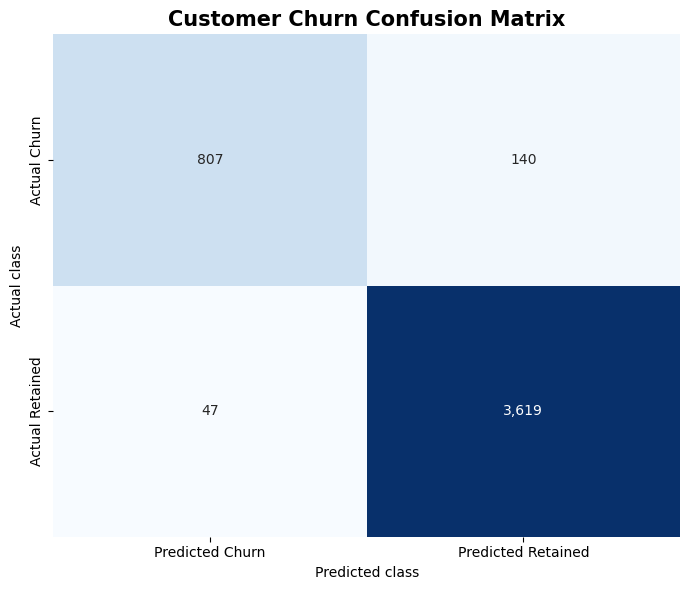

[[ 807  140]
 [  47 3619]]


In [9]:
# Report 4: confusion-matrix.png

matrix = confusion_matrix(
    y_test,
    y_prediction
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    matrix,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Predicted Churn",
        "Predicted Retained"
    ],
    yticklabels=[
        "Actual Churn",
        "Actual Retained"
    ]
)

plt.title(
    "Customer Churn Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()

plt.savefig(
    reports_dir / "confusion-matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(matrix)

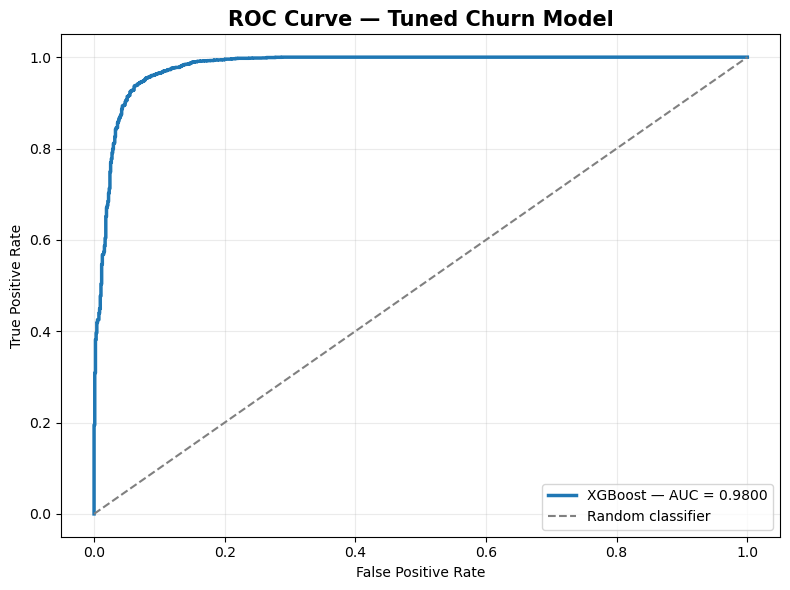

In [10]:
# Report 5: roc-curve.png
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2.5,
    label=f"XGBoost — AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve — Tuned Churn Model",
    fontsize=15,
    fontweight="bold"
)

plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    reports_dir / "roc-curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

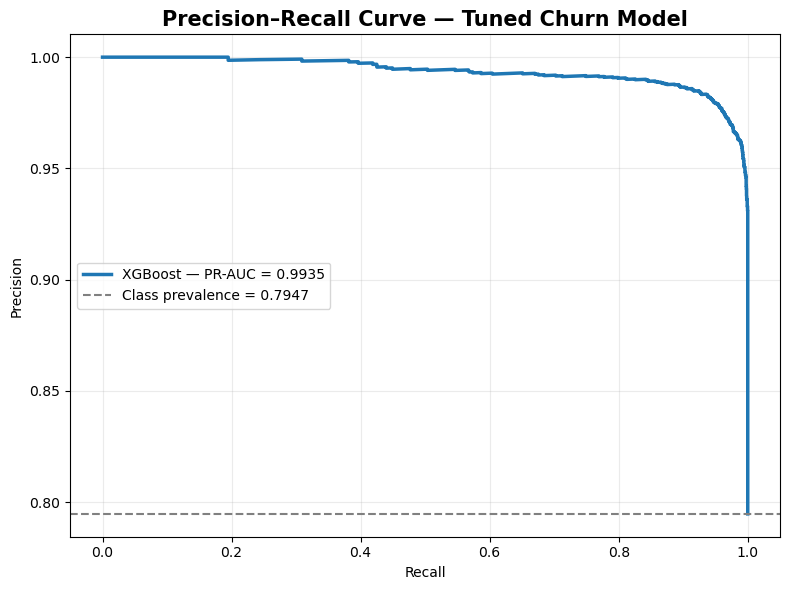

In [11]:
# Report 6: precision-recall-curve.png
curve_precision, curve_recall, _ = (
    precision_recall_curve(
        y_test,
        y_probability
    )
)

positive_class_rate = y_test.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    curve_recall,
    curve_precision,
    linewidth=2.5,
    label=f"XGBoost — PR-AUC = {pr_auc:.4f}"
)

plt.axhline(
    positive_class_rate,
    linestyle="--",
    color="gray",
    label=(
        f"Class prevalence = "
        f"{positive_class_rate:.4f}"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision–Recall Curve — Tuned Churn Model",
    fontsize=15,
    fontweight="bold"
)

plt.legend(loc="best")
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    reports_dir / "precision-recall-curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Report 7: shap-summary.png

shap_sample_size = min(
    1000,
    len(X_test)
)

X_shap = X_test.sample(
    n=shap_sample_size,
    random_state=42
)

print("SHAP sample:", X_shap.shape)

# Generate the SHAP values

explainer = shap.TreeExplainer(booster)

shap_values = explainer.shap_values(
    X_shap
)

# Create the summary plot:

plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Feature Impact — Tuned Churn Model",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    reports_dir / "shap-summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()